1 — What you want to test

You have two page variants:

A (control) and B (treatment).

For each variant you observe: number of impressions (views) and number of clicks.

CTR = clicks / impressions.

Goal: determine whether B has a different (usually higher) CTR than A.

2 — Hypotheses (two common forms)
Two-sided

𝐻
0
:
𝑝
𝐴
=
𝑝
𝐵
H
0
​
 :p
A
​
 =p
B
​
  (no difference)

𝐻
1
:
𝑝
𝐴
≠
𝑝
𝐵
H
1
​
 :p
A
​


=p
B
​


One-sided (directional, common if you expect improvement)

𝐻
0
:
𝑝
𝐴
≥
𝑝
𝐵
H
0
​
 :p
A
​
 ≥p
B
​


𝐻
1
:
𝑝
𝐴
<
𝑝
𝐵
H
1
​
 :p
A
​
 <p
B
​
  (or the other way depending on labeling)

Here
𝑝
𝐴
p
A
​
  and
𝑝
𝐵
p
B
​
  are true CTRs.

How it works


Define a goal — e.g., increase clicks on a signup button.

Create two versions:

Version A (Control) — current version (e.g., blue button).

Version B (Treatment) — modified version (e.g., red button).

Split the audience randomly into two groups.

Group 1 sees version A.

Group 2 sees version B.

Collect data — record clicks and impressions for each version.

Statistically compare the results (e.g., using a hypothesis test like a two-proportion z-test).

Decide — if B’s CTR is significantly higher, you might adopt it.

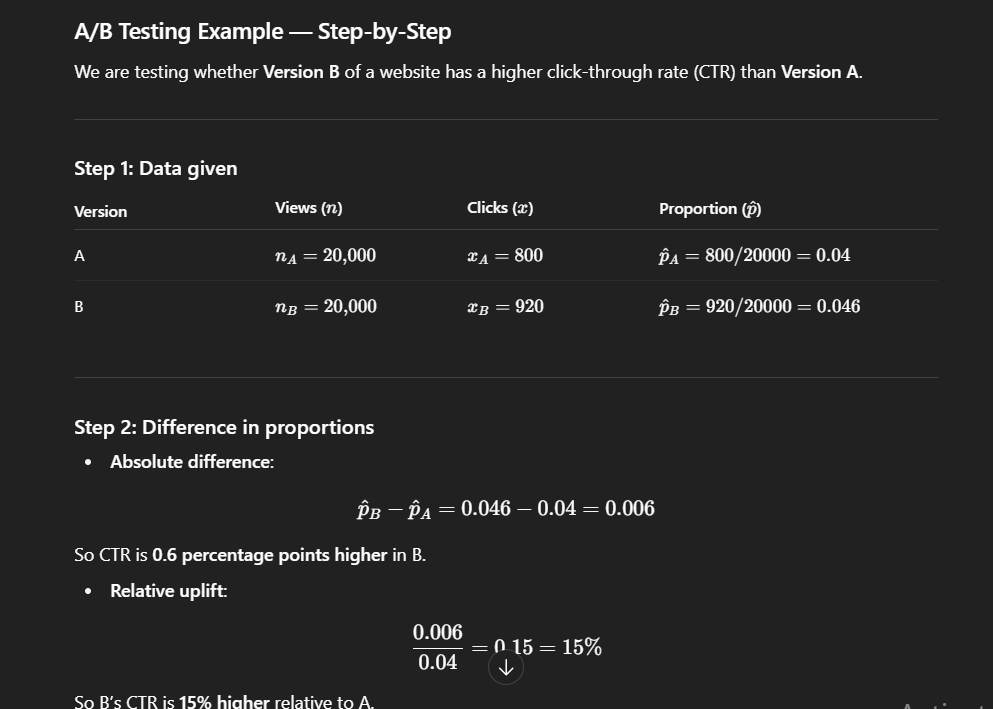

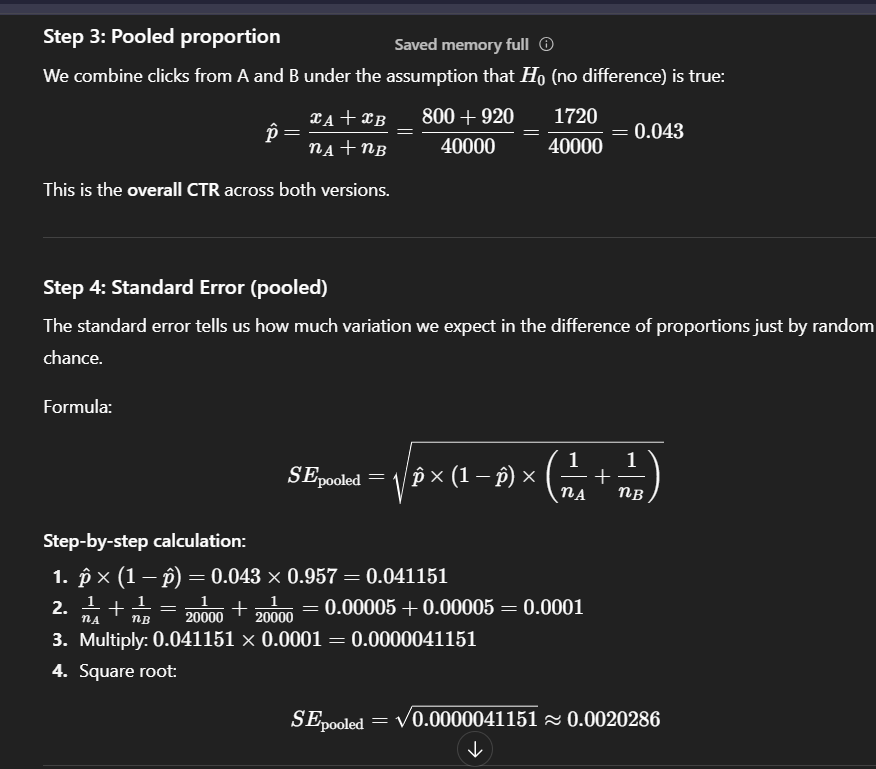

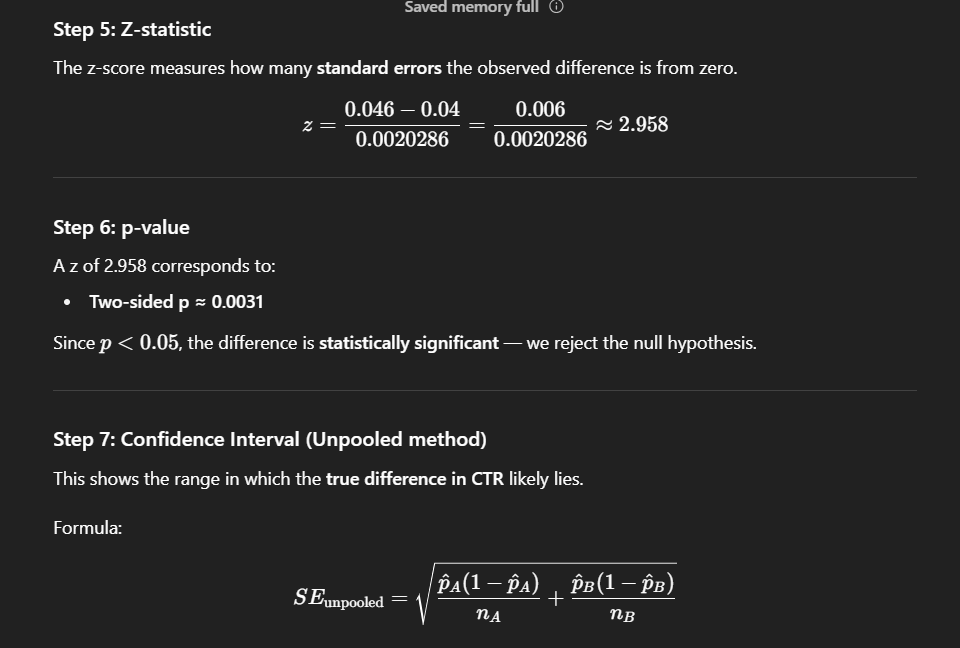

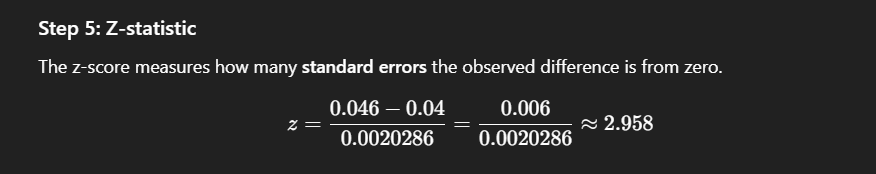

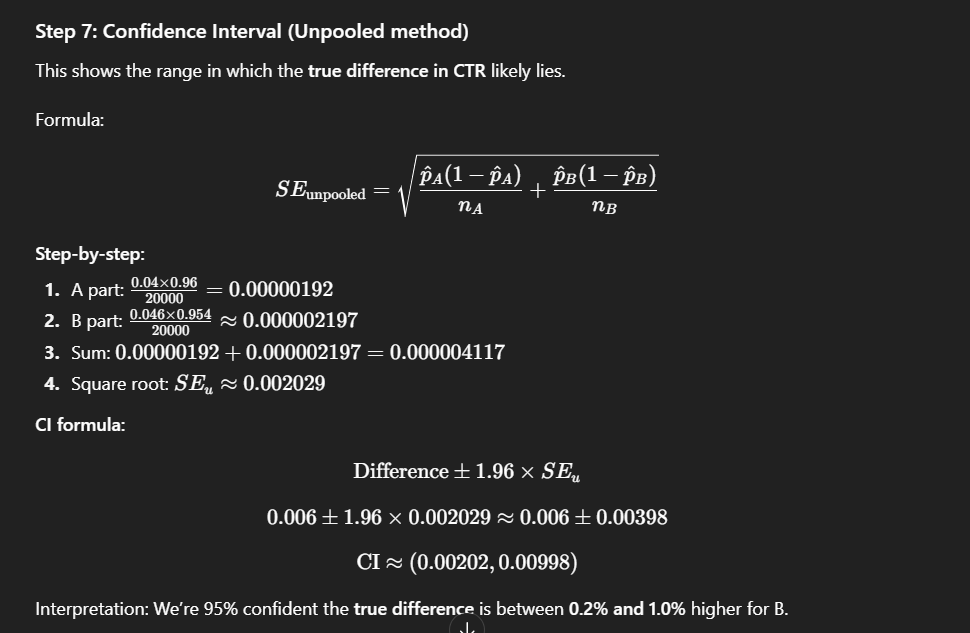

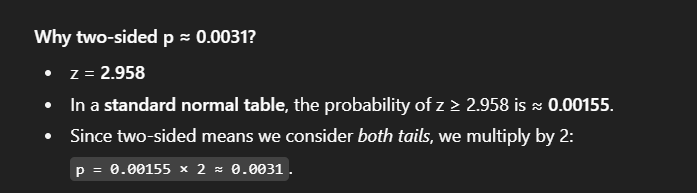

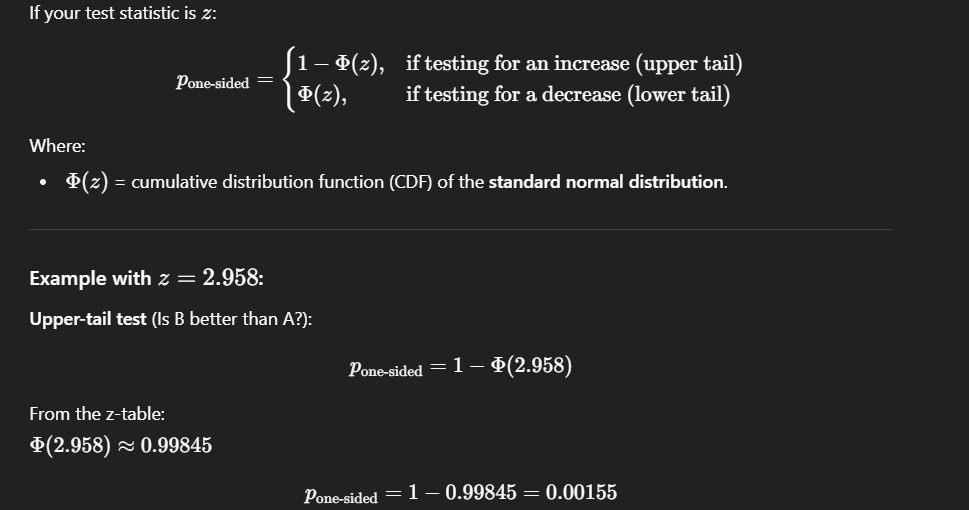

In [2]:
from google.colab import files
import pandas as pd

# Step 1: Upload the file
uploaded = files.upload()



Saving ab_data.csv to ab_data.csv


In [3]:

# Step 2: Read the uploaded CSV file (replace with your actual filename if needed)
df = pd.read_csv('ab_data.csv')

# Step 3: Preview the dataset
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [6]:

print(df['group'].value_counts())


group
treatment    147276
control      147202
Name: count, dtype: int64


In [11]:
# Number of users in each group
n_A = df[df['group'] == 'control'].shape[0]
n_B = df[df['group'] == 'treatment'].shape[0]


In [12]:
print('NA',n_A)


NA 147202


In [13]:
print('NB',n_B)


NB 147276


In [14]:

# Number of conversions in each group
x_A = df[(df['group'] == 'control') & (df['converted'] == 1)].shape[0]
x_B = df[(df['group'] == 'treatment') & (df['converted'] == 1)].shape[0]


In [15]:
print('XA',x_A)


XA 17723


In [16]:
print('XB',x_B)


XB 17514


In [17]:

# Conversion rates
p_A = x_A / n_A
p_B = x_B / n_B


In [18]:

print(f"Group A: n={n_A}, conversions={x_A}, rate={p_A:.4f}")
print(f"Group B: n={n_B}, conversions={x_B}, rate={p_B:.4f}")


Group A: n=147202, conversions=17723, rate=0.1204
Group B: n=147276, conversions=17514, rate=0.1189


In [19]:
p_pooled = (x_A + x_B) / (n_A + n_B)


In [20]:
print(f"Pooled proportion: {p_pooled:.4f}")


Pooled proportion: 0.1197


In [22]:
import math

SE_pooled = math.sqrt(p_pooled * (1 - p_pooled) * (1/n_A + 1/n_B))
print(f"Standard Error (pooled): {SE_pooled:.6f}")


Standard Error (pooled): 0.001196


In [23]:
z = (p_B - p_A) / SE_pooled
print(f"Z-score: {z:.4f}")


Z-score: -1.2369


In [24]:
from scipy.stats import norm

# Two-sided
p_value_two = 2 * (1 - norm.cdf(abs(z)))
# One-sided (B > A)
p_value_one = 1 - norm.cdf(z)



In [25]:
print(f"Two-sided p-value: {p_value_two:.6f}")
print(f"One-sided p-value: {p_value_one:.6f}")


Two-sided p-value: 0.216116
One-sided p-value: 0.891942


In [26]:
alpha = 0.05
if p_value_two < alpha:
    print("Statistically significant difference (two-sided test)")
else:
    print("No statistically significant difference (two-sided test)")



No statistically significant difference (two-sided test)


In [27]:
if p_value_one < alpha:
    print("B is significantly better than A (one-sided test)")
else:
    print("No evidence that B is better than A (one-sided test)")


No evidence that B is better than A (one-sided test)


In [28]:
# Z critical value for 95% confidence
z_critical = norm.ppf(1 - 0.05/2)  # ~1.96

# Margin of error
margin_error = z_critical * SE_pooled

# Confidence interval
ci_lower = (p_B - p_A) - margin_error
ci_upper = (p_B - p_A) + margin_error

print(f"95% Confidence Interval for (pB - pA): ({ci_lower:.6f}, {ci_upper:.6f})")


95% Confidence Interval for (pB - pA): (-0.003824, 0.000865)
